In [ ]:
!pip install -q shap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [ ]:
np.random.seed(42)

n = 600

engine_size = np.random.uniform(1.0, 4.0, n)
horsepower = 70 + engine_size * 45 + np.random.normal(0, 15, n)
weight = 900 + engine_size * 320 + np.random.normal(0, 90, n)
age = np.random.uniform(0, 15, n)
mileage = age * np.random.uniform(8000, 18000, n)

fuel_type = np.random.choice(
    ["Petrol", "Diesel", "Electric"],
    n,
    p=[0.5, 0.35, 0.15]
)

fuel_bonus = np.where(
    fuel_type == "Electric", 4000,
    np.where(fuel_type == "Diesel", 1000, 0)
)

price = (
    30000
    - age * 1500
    - mileage * 0.035
    + engine_size * 1800
    + horsepower * 20
    - weight * 2
    + fuel_bonus
    + np.random.normal(0, 1500, n)
)

price = np.clip(price, 1500, None)

car_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "weight_kg": weight,
    "age_years": age,
    "mileage_km": mileage,
    "fuel_type": fuel_type,
    "price": price
})

car_df.head()

,engine_size_L,horsepower,weight_kg,age_years,mileage_km,fuel_type,price
0,2.123620,157.609052,1530.031050,2.811179,49554.576527,Diesel,28512.167035
1,3.852143,231.453339,2072.239631,12.872656,112713.623023,Diesel,13350.268865
2,3.195982,212.213727,1920.414318,12.285953,143214.985457,Electric,17298.227726
3,2.795975,180.290261,1900.257757,8.111906,83177.967933,Diesel,21136.167561
4,1.468056,127.757777,1418.701909,10.653642,106092.491496,Diesel,13375.148509


In [ ]:
car_encoded = pd.get_dummies(car_df, columns=["fuel_type"], drop_first=True)

X = car_encoded.drop(columns=["price"])
y = car_encoded["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


              Feature  Importance
3           age_years    0.784074
4          mileage_km    0.146590
0       engine_size_L    0.024649
1          horsepower    0.020761
2           weight_kg    0.011615
6    fuel_type_Petrol    0.006327
5  fuel_type_Electric    0.005983


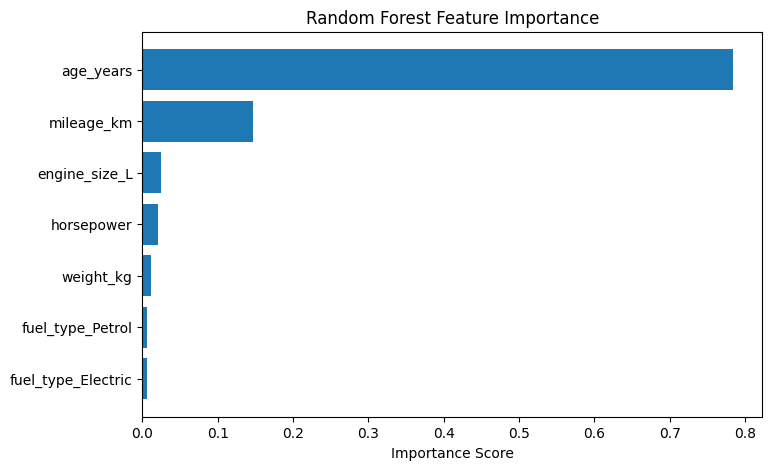

In [ ]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

              Feature  Importance
3           age_years    1.185336
4          mileage_km    0.076335
0       engine_size_L    0.034899
1          horsepower    0.018061
5  fuel_type_Electric    0.008710
6    fuel_type_Petrol    0.008540
2           weight_kg    0.002922


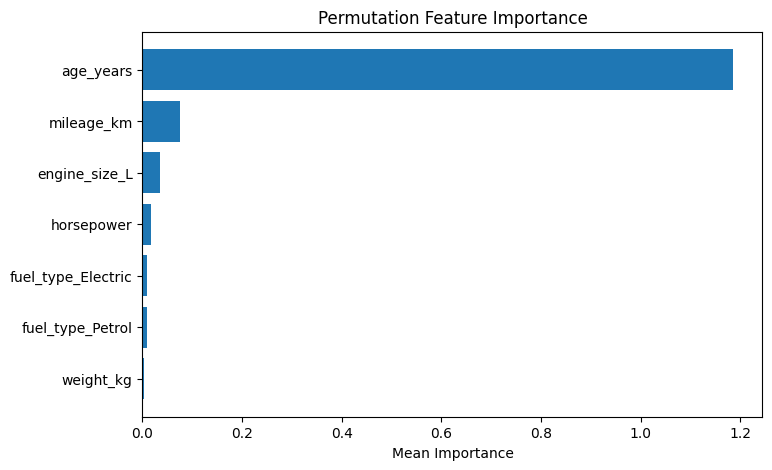

In [ ]:
perm_result = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

print(perm_df)

plt.figure(figsize=(8,5))
plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)
plt.title("Permutation Feature Importance")
plt.xlabel("Mean Importance")
plt.gca().invert_yaxis()
plt.show()

/tmp/ipykernel_1637/111165208.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


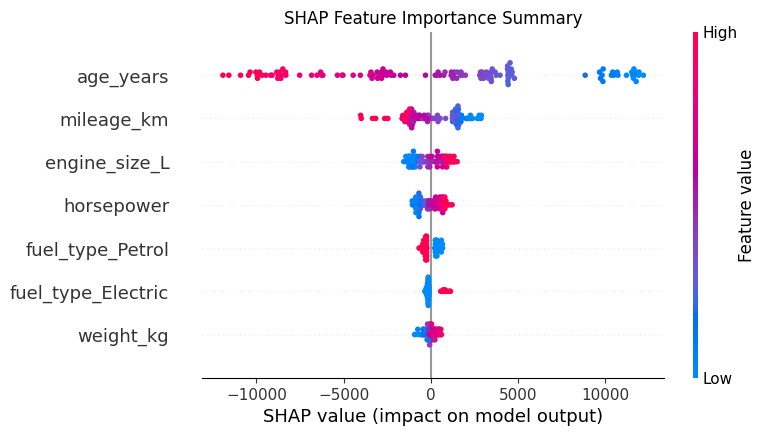

In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance Summary")
plt.show()

/tmp/ipykernel_1637/111165208.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


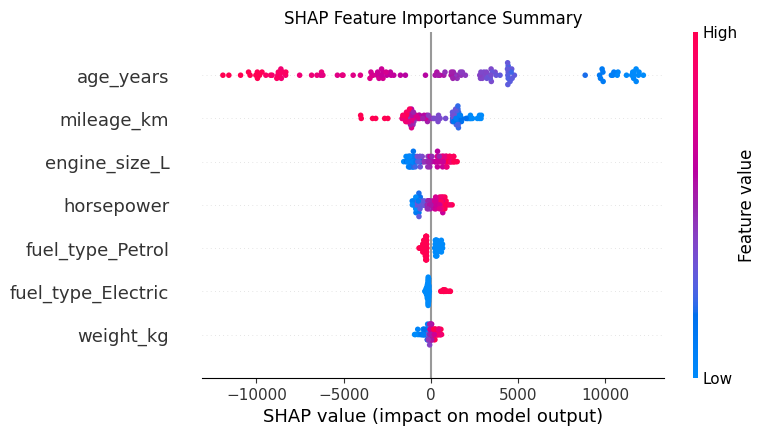

In [ ]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance Summary")
plt.show()

In [ ]:
print("Feature Ranking (Highest to Lowest Importance)\n")

for i, row in enumerate(importance_df.itertuples(index=False), start=1):
    print(f"{i}. {row.Feature} : {row.Importance:.4f}")

Feature Ranking (Highest to Lowest Importance)

1. age_years : 0.7841
2. mileage_km : 0.1466
3. engine_size_L : 0.0246
4. horsepower : 0.0208
5. weight_kg : 0.0116
6. fuel_type_Petrol : 0.0063
7. fuel_type_Electric : 0.0060
